# Food Demand Prediction

# Preprocessing and Modeling Procedure
Upon receiving the dataset, I obtained five files: fulfilment center, meal info, sample submission, train, and test. The key focus was on the fulfilment center, meal info, train, and test files. I began by merging the fulfilment center and meal info data with the train and test datasets, as these features were crucial to include. After merging, the train dataset contained 456,548 rows and 15 columns, while the test dataset had 32,573 rows and 14 columns, excluding the target variable. The train dataset spans weeks 1 to 145, with the objective of forecasting food demand for weeks 146 to 155.

Next, I performed an exploratory data analysis (EDA) to gain deeper insights into the dataset. During the modeling process, I developed the model in two stages: before and after feature engineering. After completing the feature engineering, I proceeded with hyperparameter tuning.


# Import Libraries

In [ ]:
# For data manipulation and analysis
import pandas as pd

# For numerical operations
import numpy as np

# For creating visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# For regular expressions
import re

# For scikit-learn models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# For scikit-learn features
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna

# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")

# Import File

In [ ]:
# Import fulfilment center file
center = pd.read_csv("/kaggle/input/food-demand-forecasting/fulfilment_center_info.csv")

# Import meal file
meal = pd.read_csv("/kaggle/input/food-demand-forecasting/meal_info.csv")

# Import sample submission file
sample = pd.read_csv("/kaggle/input/food-demand-forecasting/sample_submission.csv")

# Import train file
train = pd.read_csv("/kaggle/input/food-demand-forecasting/train.csv")

# Import test file
test = pd.read_csv("/kaggle/input/food-demand-forecasting/test.csv")

In [ ]:
# Read fulfilment center info
center.info()

In [ ]:
# Read meal info
meal.info()

In [ ]:
# Read sample submission info
sample.info()

In [ ]:
# Read train info
train.info()

In [ ]:
# Read test info
test.info()

# Merge Dataset

## Merge Train Dataset

In [ ]:
# Merge datasets for train dataframe
train = pd.merge(train, center, how = "left", on = "center_id")
train = pd.merge(train, meal, how = "left", on = "meal_id")
train.info()

In [ ]:
# Rearrange columns
col = train.pop("city_code")
train.insert(3, "city_code", col)

col = train.pop("region_code")
train.insert(4, "region_code", col)

col = train.pop("center_type")
train.insert(5, "center_type", col)

col = train.pop("op_area")
train.insert(6, "op_area", col)

col = train.pop("category")
train.insert(8, "category", col)

col = train.pop("cuisine")
train.insert(9, "cuisine", col)

## Merge Test Dataset

In [ ]:
# Merge datasets for test dataframe
test = pd.merge(test, center, how = "left", on = "center_id")
test = pd.merge(test, meal, how = "left", on = "meal_id")
test.info()

In [ ]:
# Rearrange columns
col = test.pop("city_code")
test.insert(3, "city_code", col)

col = test.pop("region_code")
test.insert(4, "region_code", col)

col = test.pop("center_type")
test.insert(5, "center_type", col)

col = test.pop("op_area")
test.insert(6, "op_area", col)

col = test.pop("category")
test.insert(8, "category", col)

col = test.pop("cuisine")
test.insert(9, "cuisine", col)

# Read Dataset

## Read Train Dataset

In [ ]:
# Statistical description
train.describe()

In [ ]:
# List all missing values
train.isnull().sum().sum()

In [ ]:
# List all potential duplicate rows
train.duplicated().sum()

In [ ]:
# Column information
train.info()

In [ ]:
train.sample()

## Read Test Dataset

In [ ]:
# Statistical description
test.describe()

In [ ]:
# List all missing values
test.isnull().sum().sum()

In [ ]:
# List all potential duplicate rows
test.duplicated().sum()

In [ ]:
# Column information
test.info()

In [ ]:
test.sample()

# Data Preprocessing

In [ ]:
# Combining two dataframes
data = [train,test]

## ID
The "ID" column was dropped because the number of unique values matches the number of rows, meaning it doesn't contribute any meaningful information to the analysis.

In [ ]:
# List number of rows in train dataframe
train_rows = len(train)
print(train_rows)

# List number of rows in test dataframe
test_rows = len(test)
print(test_rows)

# Number of unique values in "id" column for both dataframes
train_id = train["id"].nunique()
test_id = test["id"].nunique()

print(train_id)
print(test_id)

In [ ]:
# Dropping "ID" column for both dataframes
for dataset in data:
    dataset.drop(["id"], axis = 1, inplace = True)

## Week
The "Week" column ranges from weeks 1 to 145 in the train dataset and from weeks 146 to 155 in the test dataset.

In [ ]:
# Number of unique values in "week" column for both dataframes
train_week = train["week"].nunique()
test_week = test["week"].nunique()

print(train_week)
print(test_week)

In [ ]:
# Number of counts in "week" column for both dataframes
train_week_count = train["week"].value_counts()
test_week_count = test["week"].value_counts()

print(train_week_count)
print("-" * 100)
print(test_week_count)

## Center ID
The fulfilment center, identified as "Center ID" in the column, has 77 unique values, with each center ID linked to a specific city code, region code, center type, and operations area.

In [ ]:
# Number of unique values in "center_id" column for both dataframes
train_center_id = train["center_id"].nunique()
test_center_id = test["center_id"].nunique()

print(train_center_id)
print(test_center_id)

In [ ]:
# Number of counts in "center_id" column for both dataframes
train_center_id_count = train["center_id"].value_counts()
test_center_id_count = test["center_id"].value_counts()

print(train_center_id_count)
print("-" * 100)
print(test_center_id_count)

## City Code
Refer to fulfilment center dataset.

In [ ]:
# Number of unique values in "city_code" column for both dataframes
train_city_code = train["city_code"].nunique()
test_city_code = test["city_code"].nunique()

print(train_city_code)
print(test_city_code)

In [ ]:
# Number of counts in "city_code" column for both dataframes
train_city_code_count = train["city_code"].value_counts()
test_city_code_count = test["city_code"].value_counts()

print(train_city_code_count)
print("-" * 100)
print(test_city_code_count)

## Region Code
Refer to fulfilment center dataset.

In [ ]:
# Number of unique values in "region_code" column for both dataframes
train_region_code = train["region_code"].nunique()
test_region_code = test["region_code"].nunique()

print(train_region_code)
print(test_region_code)

In [ ]:
# Number of counts in "region_code" column for both dataframes
train_region_code_count = train["region_code"].value_counts()
test_region_code_count = test["region_code"].value_counts()

print(train_region_code_count)
print("-" * 100)
print(test_region_code_count)

## Center Type
Refer to fulfilment center dataset.

In [ ]:
# Number of unique values in "center_type" column for both dataframes
train_center_type = train["center_type"].nunique()
test_center_type = test["center_type"].nunique()

print(train_center_type)
print(test_center_type)

In [ ]:
# Number of counts in "center_type" column for both dataframes
train_center_type_count = train["center_type"].value_counts()
test_center_type_count = test["center_type"].value_counts()

print(train_center_type_count)
print("-" * 100)
print(test_center_type_count)

## Op Area
Refer to fulfilment center dataset.

In [ ]:
# Number of unique values in "op_area" column for both dataframes
train_op_area = train["op_area"].nunique()
test_op_area = test["op_area"].nunique()

print(train_op_area)
print(test_op_area)

In [ ]:
# Number of counts in "op_area" column for both dataframes
train_op_area_count = train["op_area"].value_counts()
test_op_area_count = test["op_area"].value_counts()

print(train_op_area_count)
print("-" * 100)
print(test_op_area_count)

## Meal ID
The "Meal ID" column contains 51 unique values, each of which is associated with a specific category and cuisine.

In [ ]:
# Number of unique values in "meal_id" column for both dataframes
train_meal_id = train["meal_id"].nunique()
test_meal_id = test["meal_id"].nunique()

print(train_meal_id)
print(test_meal_id)

In [ ]:
# Number of counts in "meal_id" column for both dataframes
train_meal_id_count = train["meal_id"].value_counts()
test_meal_id_count = test["meal_id"].value_counts()

print(train_meal_id_count)
print("-" * 100)
print(test_meal_id_count)

## Category
Refer to meal info dataset.

In [ ]:
# Number of unique values in "category" column for both dataframes
train_category = train["category"].nunique()
test_category = test["category"].nunique()

print(train_category)
print(test_category)

In [ ]:
# Number of counts in "category" column for both dataframes
train_category_count = train["category"].value_counts()
test_category_count = test["category"].value_counts()

print(train_category_count)
print("-" * 100)
print(test_category_count)

## Cuisine
Refer to meal info dataset.

In [ ]:
# Number of unique values in "cuisine" column for both dataframes
train_cuisine = train["cuisine"].nunique()
test_cuisine = test[ "cuisine"].nunique()

print(train_cuisine)
print(test_cuisine)

In [ ]:
# Number of counts in "cuisine" column for both dataframes
train_cuisine_count = train["cuisine"].value_counts()
test_cuisine_count = test["cuisine"].value_counts()

print(train_cuisine_count)
print("-" * 100)
print(test_cuisine_count)

## Checkout Price
The "Checkout Price" column is the final price paid after discounts or adjustments.

In [ ]:
# Converting "checkout_price" column into Int64 for both dataframes
for dataset in data:
    dataset["checkout_price"] = dataset["checkout_price"].astype("int")

## Base Price
The "Base Price" column is the original price before any discounts or adjustments.

In [ ]:
# Converting "base_price" column into Int64 for both dataframes
for dataset in data:
    dataset["base_price"] = dataset["base_price"].astype("int")

## Emailer for Promotion
The "Emailer for Promotion" column indicates whether an item was promoted via email, with two unique values: 0 (not promoted) and 1 (promoted).

In [ ]:
# Number of unique values in "emailer_for_promotion" column for both dataframes
train_emailer_for_promotion = train["emailer_for_promotion"].nunique()
test_emailer_for_promotion = test["emailer_for_promotion"].nunique()

print(train_emailer_for_promotion)
print(test_emailer_for_promotion)

In [ ]:
# Number of counts in "emailer_for_promotion" column for both dataframes
train_emailer_for_promotion_count = train["emailer_for_promotion"].value_counts()
test_emailer_for_promotion_count = test["emailer_for_promotion"].value_counts()

print(train_emailer_for_promotion_count)
print("-" * 100)
print(test_emailer_for_promotion_count)

## Homepage Featured
The "Homepage Featured" column shows whether an item was featured on the homepage, with two unique values: 0 (not featured) and 1 (featured).

In [ ]:
# Number of unique values in "homepage_featured" column for both dataframes
train_homepage_featured = train["homepage_featured"].nunique()
test_homepage_featured = test["homepage_featured"].nunique()

print(train_homepage_featured)
print(test_homepage_featured)

In [ ]:
# Number of counts in "homepage_featured" column for both dataframes
train_train_homepage_featured_count = train["homepage_featured"].value_counts()
test_train_homepage_featured_count = test["homepage_featured"].value_counts()

print(train_train_homepage_featured_count)
print("-" * 100)
print(test_train_homepage_featured_count)

## Updated Column Information

In [ ]:
train.info()

In [ ]:
test.info()

# Data Visualization

## Relationship between Week Number and Number of Orders
From the graph, it's evident that the number of weekly orders from weeks 1 to 145 ranges between 0 and 25000, with any values exceeding 5000 appearing as outliers based on visual observation.

In [ ]:
train.plot(kind = "scatter", x = "week", y = "num_orders",
           title = "Number of Orders by Week", xlabel = "Week Number",
           ylabel = "Number of Orders", color = "blue", grid = True)

## Count of Category
The category countplot reveals a total of 14 categories, with beverages being the most popular.

In [ ]:
# Calculate the order of "category" based on the counts, sorted from greatest to least
category_order = train["category"].value_counts().index

# Figure size (10, 4)
plt.figure(figsize = (10, 4))

# Count plot for "category"
sns.countplot(data = train, x = "category", order = category_order)

# Plot details
plt.xlabel("Category")
plt.xticks(rotation = 45)
plt.ylabel("Count")
plt.title("Category Countplot")

# Show the plot
plt.show()

## Count of Cuisine
Regarding cuisine, there are four types offered, with Italian being the most popular.

In [ ]:
# Calculate the order of "cuisine" based on the counts, sorted from greatest to least
cuisine_order = train["cuisine"].value_counts().index

# Figure size (10, 4)
plt.figure(figsize = (10, 4))

# Count plot for "cuisine"
sns.countplot(data = train, x = "cuisine", order = cuisine_order)

# Plot details
plt.xlabel("Cuisine")
plt.xticks(rotation = 45)
plt.ylabel("Count")
plt.title("Cuisine Countplot")

# Show the plot
plt.show()

## Heatmap Analysis: Key Feature Correlations with Number of Orders
The heatmap analysis shows that the op area, cuisine, checkout price, base price, emailer for promotion, and homepage featured are the features most strongly correlated with the target variable, the number of orders.

In [ ]:
# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Iterate through each dataset in the data list
for dataset in data:

    # Apply LabelEncoder to each specified column independently
    for col in ["center_type", "category", "cuisine"]:
        dataset[col] = label_encoder.fit_transform(dataset[col])

In [ ]:
# Figure size
plt.figure(figsize = (14, 10))

# Plot labels
sns.heatmap(train.corr(), cmap = "YlGnBu", annot = True)
plt.xticks(rotation = 45, ha = "right", fontsize = 12)
plt.yticks(fontsize = 12)
plt.tight_layout()
plt.show()

# Model Building Before Feature Engineering  
The train data covered weeks 1 to 117, while the test data spanned weeks 118 to 145. The dataset was split with 80% for training and 20% for testing within the train dataset. The first stage of the model was developed over five iterations.

**First Iteration:** Used default settings with no modifications.

**Second Iteration:** Outliers were removed by excluding orders above 5000.

**Third Iteration:** One-hot encoding was applied to the "center_id", "city_code", "center_type", "meal_id", "category", and "cuisine" columns.

**Fourth Iteration:** Combined the procedures from the second and third iterations.

**Fifth Iteration:** Included only the features most strongly correlated with the target variable, number of orders, as identified in the heatmap analysis.

Ultimately, Random Forest emerged as the best-performing model in the fourth iteration, achieving an R-squared score of 76%, followed closely by Gradient Boosting.

| Iteration | Model                        | R-Squared Score |
|-----------|------------------------------|-----------------|
| 1         | k-Nearest Neighbors Regression | 0.5228          |
|           | Decision Tree Regression      | 0.5672          |
|           | Random Forest Regression      | 0.7291          |
|           | Gradient Boosting Regression  | 0.5862          |
| 2         | k-Nearest Neighbors Regression | 0.5606          |
|           | Decision Tree Regression      | 0.6072          |
|           | Random Forest Regression      | 0.7565          |
|           | Gradient Boosting Regression  | 0.6138          |
| 3         | k-Nearest Neighbors Regression | 0.1111          |
|           | Decision Tree Regression      | 0.6165          |
|           | Random Forest Regression      | 0.7452          |
|           | Gradient Boosting Regression  | 0.6574          |
| 4         | k-Nearest Neighbors Regression | 0.1332          |
|           | Decision Tree Regression      | 0.6285          |
|           | Random Forest Regression      | 0.7603          |
|           | Gradient Boosting Regression  | 0.6819          |
| 5         | k-Nearest Neighbors Regression | 0.2599          |
|           | Decision Tree Regression      | 0.2157          |
|           | Random Forest Regression      | 0.4067          |
|           | Gradient Boosting Regression  | 0.4357          |

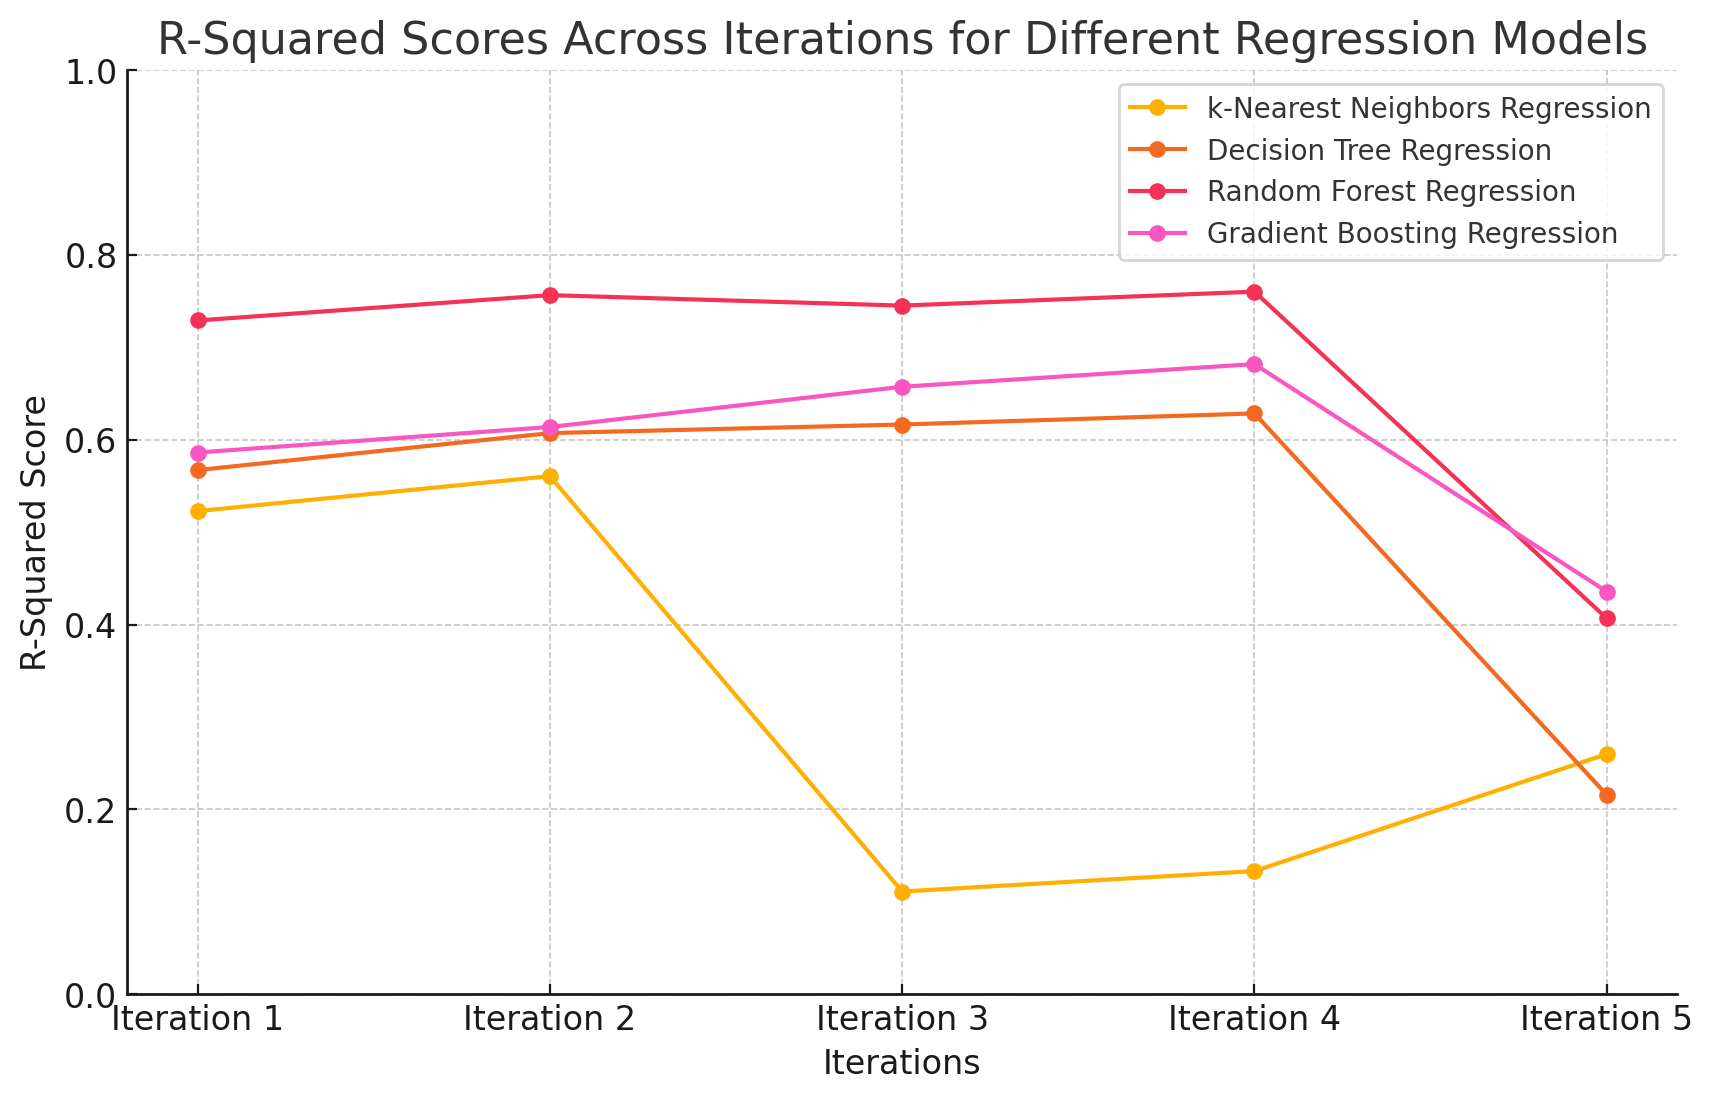!



## Iteration 1

In [ ]:
# Split the data into train and test
train_iteration_1 = train[train["week"] <= 117]
test_iteration_1 = train[train["week"] > 117]

# Train data
train_X = train_iteration_1.drop(["num_orders"], axis = 1)
train_y = train_iteration_1["num_orders"]

# Test data
test_X = test_iteration_1.drop(["num_orders"], axis = 1)
test_y = test_iteration_1["num_orders"]

In [ ]:
# Dictionary of regression models
regression_models = {
    "k-Nearest Neighbors Regression": KNeighborsRegressor(),
    "Decision Tree Regression": DecisionTreeRegressor(random_state = 42),
    "Random Forest Regression": RandomForestRegressor(random_state = 42),
    "Gradient Boosting Regression": GradientBoostingRegressor(random_state = 42, verbose = 0)
}

In [ ]:
%%time

# Dictionary to store the evaluation metrics for each model
model_metrics = {
    "model_name": [],
    "r2_score": [],
    "mean_absolute_error": [],
    "mean_squared_error": []
}

# Train and evaluate each model
for name, reg in regression_models.items():
    reg.fit(train_X, train_y)
    y_predict = reg.predict(test_X)

    r2 = r2_score(test_y, y_predict)
    mae = mean_absolute_error(test_y, y_predict)
    mse = mean_squared_error(test_y, y_predict)

    # Print the metrics
    print(f"{name} - R-Squared Score: {r2}")
    print(f"{name} - Mean Absolute Error: {mae}")
    print(f"{name} - Mean Squared Error: {mse}")
    print("-" * 100)

## Iteration 2

In [ ]:
# Copy of original dataframe
train_2 = train.copy()

# Drop outliers in "num_orders" column
train_2 = train_2.query("num_orders < 5000")

In [ ]:
# Split the data into train and test
train_iteration_2 = train_2[train_2["week"] <= 117]
test_iteration_2 = train_2[train_2["week"] > 117]

# Train data
train_X = train_iteration_2.drop(["num_orders"], axis = 1)
train_y = train_iteration_2["num_orders"]

# Test data
test_X = test_iteration_2.drop(["num_orders"], axis = 1)
test_y = test_iteration_2["num_orders"]

In [ ]:
%%time

# Dictionary to store the evaluation metrics for each model
model_metrics = {
    "model_name": [],
    "r2_score": [],
    "mean_absolute_error": [],
    "mean_squared_error": []
}

# Train and evaluate each model
for name, reg in regression_models.items():
    reg.fit(train_X, train_y)
    y_predict = reg.predict(test_X)

    r2 = r2_score(test_y, y_predict)
    mae = mean_absolute_error(test_y, y_predict)
    mse = mean_squared_error(test_y, y_predict)

    # Print the metrics
    print(f"{name} - R-Squared Score: {r2}")
    print(f"{name} - Mean Absolute Error: {mae}")
    print(f"{name} - Mean Squared Error: {mse}")
    print("-" * 100)

## Iteration 3

In [ ]:
# Copy of original dataframe
train_3 = train.copy()

# Apply one hot encoding
one_hot_encoding_columns = ["center_id", "city_code", "center_type", "meal_id", "category", "cuisine"]
train_3 = pd.get_dummies(data = train_3, columns = one_hot_encoding_columns)

In [ ]:
# Split the data into train and test
train_iteration_3 = train_3[train_3["week"] <= 117]
test_iteration_3 = train_3[train_3["week"] > 117]

# Train data
train_X = train_iteration_3.drop(["num_orders"], axis = 1)
train_y = train_iteration_3["num_orders"]

# Test data
test_X = test_iteration_3.drop(["num_orders"], axis = 1)
test_y = test_iteration_3["num_orders"]

In [ ]:
%%time

# Dictionary to store the evaluation metrics for each model
model_metrics = {
    "model_name": [],
    "r2_score": [],
    "mean_absolute_error": [],
    "mean_squared_error": []
}

# Train and evaluate each model
for name, reg in regression_models.items():
    reg.fit(train_X, train_y)
    y_predict = reg.predict(test_X)

    r2 = r2_score(test_y, y_predict)
    mae = mean_absolute_error(test_y, y_predict)
    mse = mean_squared_error(test_y, y_predict)

    # Print the metrics
    print(f"{name} - R-Squared Score: {r2}")
    print(f"{name} - Mean Absolute Error: {mae}")
    print(f"{name} - Mean Squared Error: {mse}")
    print("-" * 100)

## Iteration 4

In [ ]:
# Copy of original dataframe
train_4 = train.copy()

# Drop outliers in "num_orders" column
train_4 = train_4.query("num_orders < 5000")

# Apply one hot encoding
one_hot_encoding_columns = ["center_id", "city_code", "center_type", "meal_id", "category", "cuisine"]
train_4 = pd.get_dummies(data = train_4, columns = one_hot_encoding_columns)

In [ ]:
# Split the data into train and test
train_iteration_4 = train_4[train_4["week"] <= 117]
test_iteration_4 = train_4[train_4["week"] > 117]

# Train data
train_X = train_iteration_4.drop(["num_orders"], axis = 1)
train_y = train_iteration_4["num_orders"]

# Test data
test_X = test_iteration_4.drop(["num_orders"], axis = 1)
test_y = test_iteration_4["num_orders"]

In [ ]:
%%time

# Dictionary to store the evaluation metrics for each model
model_metrics = {
    "model_name": [],
    "r2_score": [],
    "mean_absolute_error": [],
    "mean_squared_error": []
}

# Train and evaluate each model
for name, reg in regression_models.items():
    reg.fit(train_X, train_y)
    y_predict = reg.predict(test_X)

    r2 = r2_score(test_y, y_predict)
    mae = mean_absolute_error(test_y, y_predict)
    mse = mean_squared_error(test_y, y_predict)

    # Print the metrics
    print(f"{name} - R-Squared Score: {r2}")
    print(f"{name} - Mean Absolute Error: {mae}")
    print(f"{name} - Mean Squared Error: {mse}")
    print("-" * 100) 

## Iteration 5

In [ ]:
# Copy of original dataframe
train_5 = train[["week","op_area","cuisine","checkout_price","base_price","emailer_for_promotion","homepage_featured","num_orders"]]

# Drop outliers in "num_orders" column
train_5 = train_5.query("num_orders < 5000")

# Apply one hot encoding
one_hot_encoding_columns = ["cuisine"]
train_5 = pd.get_dummies(data = train_5, columns = one_hot_encoding_columns)

In [ ]:
# Split the data into train and test
train_iteration_5 = train_5[train_5["week"] <= 117]
test_iteration_5 = train_5[train_5["week"] > 117]

# Train data
train_X = train_iteration_5.drop(["week","num_orders"], axis = 1)
train_y = train_iteration_5["num_orders"]

# Test data
test_X = test_iteration_5.drop(["week","num_orders"], axis = 1)
test_y = test_iteration_5["num_orders"]

In [ ]:
%%time

# Dictionary to store the evaluation metrics for each model
model_metrics = {
    "model_name": [],
    "r2_score": [],
    "mean_absolute_error": [],
    "mean_squared_error": []
}

# Train and evaluate each model
for name, reg in regression_models.items():
    reg.fit(train_X, train_y)
    y_predict = reg.predict(test_X)

    r2 = r2_score(test_y, y_predict)
    mae = mean_absolute_error(test_y, y_predict)
    mse = mean_squared_error(test_y, y_predict)

    # Print the metrics
    print(f"{name} - R-Squared Score: {r2}")
    print(f"{name} - Mean Absolute Error: {mae}")
    print(f"{name} - Mean Squared Error: {mse}")
    print("-" * 100) 

# Feature Engineering
Several new features were engineered to enhance the dataset:

**Discount Rate & Meal Profitability:** Calculated to show the discount applied and the profit margin per meal.

**Profitability Percentage:** Represents meal profitability as a percentage of the base price.

**Combination Features:** Merged center type with city code, category with cuisine, center ID with category, and category with center type to capture interactions.

**Price Change Rate & Food Price Trend:** Measures price fluctuations and trends over time.

**Promotional Combinations:** Combined emailer promotions with homepage features to explore their joint impact.

**Label Encoding:** Applied to the new combination features for easier model training.

In [ ]:
# Discount rate
for dataset in data:
  dataset["discount_rate"] = (dataset["base_price"] - dataset["checkout_price"]) / dataset["base_price"]
  dataset["discount_rate"] = dataset["discount_rate"].astype("int")

# Meal profitability
for dataset in data:
  dataset["meal_profitability"] = dataset["base_price"] - dataset["checkout_price"] 
  dataset["meal_profitability"] = dataset["meal_profitability"].astype("int")

# Profitability percentage of food
for dataset in data:
  dataset["meal_profitability_percentage"] = (dataset["meal_profitability"] / dataset["base_price"]) * 100
  dataset["meal_profitability_percentage"] = dataset["meal_profitability_percentage"].astype("int")

# Center type and city code combination
for dataset in data:
  dataset["center_type_city_code"] = dataset["center_type"].astype(str) + "_" + dataset["city_code"].astype(str)

# Category and cuisine combination
for dataset in data:
  dataset["category_cuisine"] = dataset["category"].astype(str) + "_" + dataset["cuisine"].astype(str)

# Center ID and category combination
for dataset in data:
  dataset["center_id_category"] = dataset["center_id"].astype(str) + "_" + dataset["category"].astype(str)

# Price change rate
for dataset in data:
  dataset["price_change_rate"] = (dataset["checkout_price"] - dataset["base_price"]) / dataset["base_price"]
  dataset["price_change_rate"] = dataset["price_change_rate"].astype("int")

# Food price trend
for dataset in data:
  dataset["food_price_trend"] = dataset.groupby("meal_id")["base_price"].transform(lambda x: x.diff())
  dataset["food_price_trend"] = dataset["food_price_trend"].fillna(0)
  dataset["food_price_trend"] = dataset["food_price_trend"].astype("int")


# Category and center type combination
for dataset in data:
  dataset["category_center_type"] = dataset["category"].astype(str) + "_" + dataset["center_type"].astype(str)

# Emailer for promotion and homepage featured combination
for dataset in data:
  dataset["featured_shown"] = dataset["emailer_for_promotion"].astype(str) + "_" + dataset["homepage_featured"].astype(str)

# Iterate through each dataset in the data list
for dataset in data:

    # Apply LabelEncoder to each specified column independently
    for col in ["center_type_city_code", "category_cuisine", "center_id_category", "category_center_type", "featured_shown"]:
        dataset[col] = label_encoder.fit_transform(dataset[col])

# Model Building After Feature Engineering
In the second stage, the focus was solely on Random Forest and Gradient Boosting. The model was refined by incorporating feature engineering and removing outliers for orders above 5000. As a result, the R-squared score for Random Forest improved to 77%, while Gradient Boosting saw a 4% drop from its peak of 68% in the first stage's iteration 4.

| Model                        | R-Squared Score | Mean Absolute Error | Mean Squared Error |
|------------------------------|-----------------|---------------------|--------------------|
| Random Forest Regression      | 0.7706          | 85.32               | 26,376.09          |
| Gradient Boosting Regression  | 0.6425          | 115.15              | 41,107.54          |


In [ ]:
# Copy of original dataframe
train_6 = train.copy()

# Drop outliers in "num_orders" column
train_6 = train_6.query("num_orders < 5000")

In [ ]:
# Split the data into train and test
train_iteration_6 = train_6[train_6["week"] <= 117]
test_iteration_6 = train_6[train_6["week"] > 117]

# Train data
train_X = train_iteration_6.drop(["num_orders"], axis = 1)
train_y = train_iteration_6["num_orders"]

# Test data
test_X = test_iteration_6.drop(["num_orders"], axis = 1)
test_y = test_iteration_6["num_orders"]

In [ ]:
# Dictionary of regression models
regression_models = {
    "Random Forest Regression": RandomForestRegressor(random_state = 42),
    "Gradient Boosting Regression": GradientBoostingRegressor(random_state = 42, verbose = 0)
}

In [ ]:
%%time

# Dictionary to store the evaluation metrics for each model
model_metrics = {
    "model_name": [],
    "r2_score": [],
    "mean_absolute_error": [],
    "mean_squared_error": []
}

# Train and evaluate each model
for name, reg in regression_models.items():
    reg.fit(train_X, train_y)
    y_predict = reg.predict(test_X)

    r2 = r2_score(test_y, y_predict)
    mae = mean_absolute_error(test_y, y_predict)
    mse = mean_squared_error(test_y, y_predict)

    # Print the metrics
    print(f"{name} - R-Squared Score: {r2}")
    print(f"{name} - Mean Absolute Error: {mae}")
    print(f"{name} - Mean Squared Error: {mse}")
    print("-" * 100)

# Hyperparameter Tuning
During hyperparameter tuning, I decided to concentrate on two models: Random Forest and Gradient Boosting. While Random Forest initially outperformed Gradient Boosting, it didn’t necessarily mean it would provide the best results with further tuning. I included both models in the evaluation because Gradient Boosting exhibited a more substantial performance improvement, with a 9.57% increase from iterations 1 to 4, compared to Random Forest's 3.12% improvement. I carried out 30 trials for each model, totaling 60 trials, aiming to achieve the best mean absolute error (MAE). Since this is a regression problem, I focused on minimizing MAE, as a lower MAE corresponds to a higher R-squared.

Ultimately, Gradient Boosting outperformed Random Forest.

## Random Forest Tuning

In [ ]:
def objective(trial):
    # Define the search space for hyperparameters
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),  
        "max_depth": trial.suggest_int("max_depth", 5, 20), 
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10)
    }

    # Create and train the model with suggest hyperparameters
    model = RandomForestRegressor(**params, random_state = 42)
    model.fit(train_X, train_y)

    # Evaluate the model's performance using MAE
    y_predict = model.predict(test_X)
    mae = mean_absolute_error(test_y, y_predict)

    return mae

In [ ]:
# Create optimization study ("minimize" - regressor)
study = optuna.create_study(direction = "minimize")

In [ ]:
%%time

# Run optimization trials ("n_trails" - number of trials)
study.optimize(objective, n_trials = 30) 

In [ ]:
# Access the best params
best_params = study.best_params
print(best_params)

# Access the best score
best_score = study.best_value
print("Best score:", best_score)

## Gradient Boosting Tuning

In [ ]:
# Split the data into train and test
train_iteration_4 = train_4[train_4["week"] <= 117]
test_iteration_4 = train_4[train_4["week"] > 117]

# Train data
train_X = train_iteration_4.drop(["n um_orders"], axis = 1)
train_y = train_iteration_4["num_orders"]

# Test data
test_X = test_iteration_4.drop(["num_orders"], axis = 1)
test_y = test_iteration_4["num_orders"]

In [ ]:
def objective(trial):
    # Define the search space for hyperparameters
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0)
    }

    # Create and train the model with suggested hyperparameters
    model = GradientBoostingRegressor(**params, random_state = 42, verbose = 0)
    model.fit(train_X, train_y)

    # Evaluate the model's performance using MAE
    y_predict = model.predict(test_X)
    mae = mean_absolute_error(test_y, y_predict)

    return mae

In [ ]:
# Create optimization study ("minimize" - regressor)
study = optuna.create_study(direction = "minimize")

In [ ]:
%%time

# Run optimization trials ("n_trails" - number of trials)
study.optimize(objective, n_trials = 30) 

In [ ]:
# Access the best params
best_params = study.best_params
print(best_params)

# Access the best score
best_score = study.best_value
print("Best score:", best_score)

# Random Forest
When I constructed the model in two stages—before and after feature engineering. I noticed that Random Forest showed a slight improvement. This led me to proceed with hyperparameter tuning, but the results remained nearly the same, with no significant enhancement.

In [ ]:
# Split the data into train and test
train_iteration_6 = train_6[train_6["week"] <= 117]
test_iteration_6 = train_6[train_6["week"] > 117]

# Train data
train_X = train_iteration_6.drop(["num_orders"], axis = 1)
train_y = train_iteration_6["num_orders"]

# Test data
test_X = test_iteration_6.drop(["num_orders"], axis = 1)
test_y = test_iteration_6["num_orders"]

In [ ]:
# Best parameters for Random Forest Regressor
best_params = {"n_estimators": 83, "max_depth": 20, "min_samples_split": 6}

# Initialize the Random Forest Regressor with the best parameters
rf_model = RandomForestRegressor(n_estimators = best_params["n_estimators"], 
                                 max_depth = best_params["max_depth"], 
                                 min_samples_split = best_params["min_samples_split"],
                                 random_state = 42)


# Train and evaluate the model
rf_model.fit(train_X, train_y)
y_predict = rf_model.predict(test_X)

r2 = r2_score(test_y, y_predict)
mae = mean_absolute_error(test_y, y_predict)
mse = mean_squared_error(test_y, y_predict)

# Print the metrics
print(f"Random Forest - R-Squared Score: {r2}")
print(f"Random Forest - Mean Absolute Error: {mae}")
print(f"Random Forest - Mean Squared Error: {mse}")

In [ ]:
# Print feature importance as a bar graph
feature_importances = rf_model.feature_importances_
features = train_X.columns

# Sort the features by importance
indices = np.argsort(feature_importances)

plt.figure(figsize = (10, 8))
plt.title("Random Forest - Feature Importances")
plt.barh(range(len(indices)), feature_importances[indices], align = "center")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Importance")
plt.show()

# Gradient Boosting
When I developed the model in two stages—before and after feature engineering. Gradient Boosting showed significant improvement from iterations 1 to 4 of the first stage, peaking at iteration 4. However, after applying feature engineering, the performance actually declined. Therefore, I decided to apply hyperparameter tuning, using a data split similar to iteration 4 of the first stage, where outliers were removed and one-hot encoding was applied. This led to an improvement in the R-squared score, increasing from 68% to 80%.

In [ ]:
# Split the data into train and test
train_iteration_4 = train_4[train_4["week"] <= 117]
test_iteration_4 = train_4[train_4["week"] > 117]

# Train data
train_X = train_iteration_4.drop(["num_orders"], axis = 1)
train_y = train_iteration_4["num_orders"]

# Test data
test_X = test_iteration_4.drop(["num_orders"], axis = 1)
test_y = test_iteration_4["num_orders"]

In [ ]:
# Best parameters for Gradient Boosting Regressor
best_params = {
    "n_estimators": 128, 
    "max_depth": 9, 
    "learning_rate": 0.13888811122898775, 
    "min_samples_split": 10, 
    "subsample": 0.6751360179710408
}

# Initialize the Gradient Boosting Regressor with the best parameters 
gb_model = GradientBoostingRegressor(n_estimators = best_params["n_estimators"], 
                                     max_depth = best_params["max_depth"], 
                                     learning_rate = best_params["learning_rate"], 
                                     min_samples_split = best_params["min_samples_split"], 
                                     subsample = best_params["subsample"],
                                     random_state = 42,
                                     verbose = 0)

# Train and evaluate the model
gb_model.fit(train_X, train_y)
y_predict = gb_model.predict(test_X)

r2 = r2_score(test_y, y_predict)
mae = mean_absolute_error(test_y, y_predict)
mse = mean_squared_error(test_y, y_predict)

# Print the metrics
print(f"Gradient Boosting - R-Squared Score: {r2}")
print(f"Gradient Boosting - Mean Absolute Error: {mae}")
print(f"Gradient Boosting - Mean Squared Error: {mse}")

In [ ]:
# Plot feature importance as a bar graph
feature_importances = gb_model.feature_importances_
features = train_X.columns

# Sort the features by importance and select the top 15
indices = np.argsort(feature_importances)[-15:]

plt.figure(figsize = (10, 8))
plt.title("Gradient Boosting - Feature Importances")
plt.barh(range(len(indices)), feature_importances[indices], align = "center")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Importance")
plt.show()

# Food Demand Forecasting

## Train and Test Sets without Outlier Orders (Less than 5,000)
In this graph, I presented the train and test sets in a scatter plot, excluding outliers with fewer than 5,000 orders.

In [ ]:
# Define "train_set" and "test_set"
train_set = train.loc[(train["week"] <= 117) & (train["num_orders"] < 5000)]
test_set = train.loc[(train["week"] > 117) & (train["num_orders"] < 5000)]

# Plot details
plt.figure(figsize = (15,4))
sns.scatterplot(x = "week", y = "num_orders", data = train_set, s = 2, label = "Train Set")
sns.scatterplot(x = "week", y = "num_orders", data = test_set, s = 2, label = "Test Set")
plt.axvline(x = 117, color = "red", linewidth = 2, linestyle = "--")
plt.legend(loc = "upper right", fontsize = 15,markerscale = 4)

## Test Set Prediction
This graph is similar to the previous one, displaying the train and test sets, but it also includes the prediction results from the gradient boosting model, which achieved an R-squared score of 80%.

In [ ]:
# Using the gradient boosting model to visually predict weeks 118 to 145
test_set["num_orders_prediction"] = gb_model.predict(test_X)
test_set

In [ ]:
# Plot details
plt.figure(figsize = (15,4))
sns.scatterplot(x = "week", y = "num_orders", data = train_4, s = 2, label = "Truth Data")
sns.scatterplot(x = "week", y = "num_orders_prediction", data = test_set, s = 2, label = "Prediction")
plt.axvline(x = 117, color = "red", linewidth = 2, linestyle = "--")
plt.legend(loc = "upper right", fontsize = 15,markerscale = 4)
plt.title("Raw Data and Prediction")

## Forecasting Food Demand (Weeks 146 - 155)
As I mentioned at the beginning, the objective of this project is to predict food demand for weeks 146 to 155. I used the gradient boosting model to generate these demand forecasts.

In [ ]:
test.info()

In [ ]:
# Copy of original dataframe
test_copy = test.copy()

# Apply one hot encoding
one_hot_encoding_columns = ["center_id", "city_code", "center_type", "meal_id", "category", "cuisine"]
test_copy = pd.get_dummies(data = test_copy, columns = one_hot_encoding_columns)
test_copy.sample()

In [ ]:
predictions = gb_model.predict(test_copy)
test_copy["num_orders_prediction"] = predictions

In [ ]:
# Plot details
plt.figure(figsize = (15,4))
sns.scatterplot(x = "week", y = "num_orders_prediction", data = test_copy)
plt.title("Forecasting Food Demand (Weeks 146 - 155)")